In [95]:
import pandas as pd

url = "https://raw.githubusercontent.com/kashfihs/lab3_3202_220129/refs/heads/main/SVM/data.csv"

df = pd.read_csv(url)

print(df.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [96]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

from sklearn.model_selection import GridSearchCV

import seaborn as sns

In [97]:
#LOADDATASET
df = pd.read_csv('https://raw.githubusercontent.com/kashfihs/lab3_3202_220129/refs/heads/main/SVM/data.csv')

In [98]:
print(df.head())

print(df.shape)

print(df.info())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [99]:
#Handlemissingvalues
print(df.isnull().sum())

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [100]:
#drop unused col
df = df.drop(['id'], axis=1)

if 'Unnamed: 32' in df.columns:
    df = df.drop(['Unnamed: 32'], axis=1)

In [101]:
le = LabelEncoder()

df['diagnosis'] = le.fit_transform(df['diagnosis'])

In [102]:
X = df.drop('diagnosis', axis=1)

y = df['diagnosis']

In [103]:
#data train
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

In [104]:
#standardization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [105]:
svm = SVC(probability=True)

In [106]:
#hyperparameter tuning
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [1, 0.1, 0.01],
    'kernel': ['rbf', 'linear', 'poly'],
    'degree': [2, 3]
}

In [107]:
#grid search
grid = GridSearchCV(
    svm,
    param_grid,
    refit=True,
    verbose=2,
    cv=3
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 54 candidates, totalling 162 fits
[CV] END ...............C=0.1, degree=2, gamma=1, kernel=rbf; total time=   0.1s
[CV] END ...............C=0.1, degree=2, gamma=1, kernel=rbf; total time=   0.1s
[CV] END ...............C=0.1, degree=2, gamma=1, kernel=rbf; total time=   0.1s
[CV] END ............C=0.1, degree=2, gamma=1, kernel=linear; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=1, kernel=linear; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=1, kernel=linear; total time=   0.0s
[CV] END ..............C=0.1, degree=2, gamma=1, kernel=poly; total time=   0.1s
[CV] END ..............C=0.1, degree=2, gamma=1, kernel=poly; total time=   0.1s
[CV] END ..............C=0.1, degree=2, gamma=1, kernel=poly; total time=   0.1s
[CV] END .............C=0.1, degree=2, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .............C=0.1, degree=2, gamma=0.1, kernel=rbf; total time=   0.1s
[CV] END .............C=0.1, degree=2, gamma=0.

GridSearchCV(cv=3, estimator=SVC(probability=True),
             param_grid={'C': [0.1, 1, 10], 'degree': [2, 3],
                         'gamma': [1, 0.1, 0.01],
                         'kernel': ['rbf', 'linear', 'poly']},
             verbose=2)

In [108]:
print(grid.best_params_)

{'C': 0.1, 'degree': 2, 'gamma': 1, 'kernel': 'linear'}


In [109]:
best_model = grid.best_estimator_

In [110]:
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:,1]

In [111]:
#evaluation matrics
acc = accuracy_score(y_test, y_pred)

pre = precision_score(y_test, y_pred)

rec = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", acc)

print("Precision:", pre)

print("Recall:", rec)

print("F1 Score:", f1)

print("AUC:", auc)

Accuracy: 0.9883720930232558
Precision: 0.9629629629629629
Recall: 1.0
F1 Score: 0.9811320754716981
AUC: 0.9993589743589744


In [112]:
#CLASSIFICATION REPORT
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        60
           1       0.96      1.00      0.98        26

    accuracy                           0.99        86
   macro avg       0.98      0.99      0.99        86
weighted avg       0.99      0.99      0.99        86



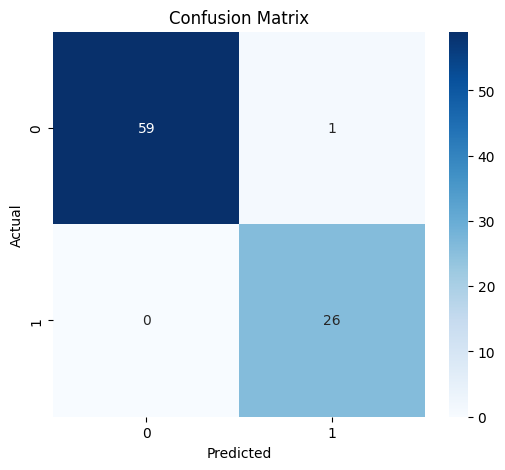

In [113]:
#CONFUSION MATRIX HEATMAP
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()

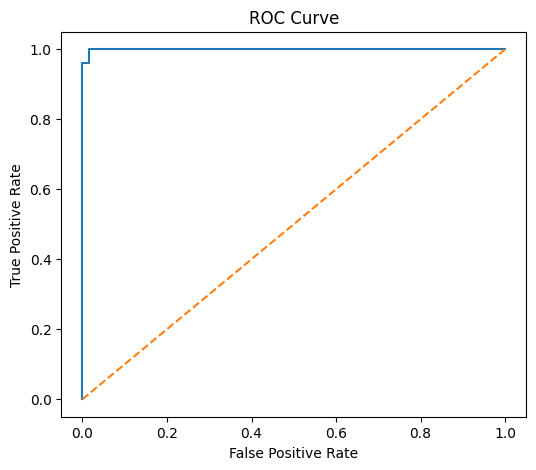

In [114]:
#ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [115]:
#SAMPLE PREDICTIONS
sample = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10],
    'Probability': y_prob[:10]
})

print(sample)

   Actual  Predicted  Probability
0       0          0     0.000015
1       0          0     0.015214
2       0          0     0.000443
3       1          1     0.999983
4       0          0     0.000202
5       0          0     0.000113
6       1          1     0.994471
7       0          0     0.019472
8       0          0     0.045016
9       0          0     0.155706


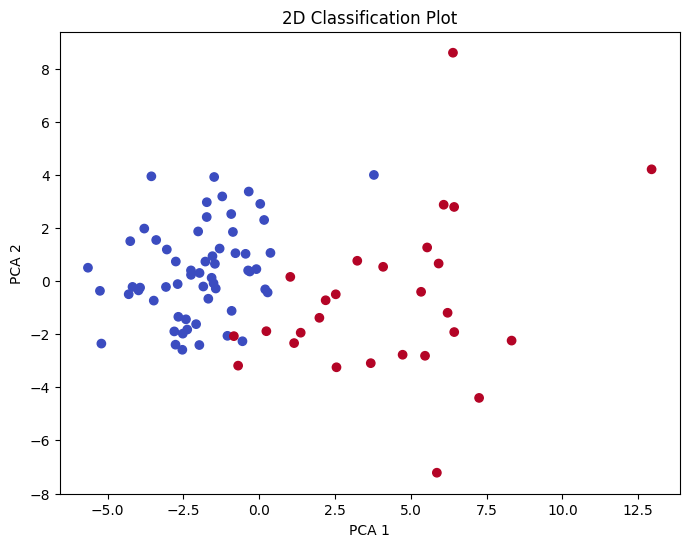

In [116]:
#2D CLASSIFICATION PLOT
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_test)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_pred,
    cmap='coolwarm'
)

plt.title("2D Classification Plot")

plt.xlabel("PCA 1")

plt.ylabel("PCA 2")

plt.show()

In [117]:
print("Accuracy:", acc)

print("Precision:", pre)

print("Recall:", rec)

print("F1 Score:", f1)

print("AUC:", auc)

Accuracy: 0.9883720930232558
Precision: 0.9629629629629629
Recall: 1.0
F1 Score: 0.9811320754716981
AUC: 0.9993589743589744


In [118]:
sample = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10],
    'Probability': y_prob[:10]
})

print(sample)

   Actual  Predicted  Probability
0       0          0     0.000015
1       0          0     0.015214
2       0          0     0.000443
3       1          1     0.999983
4       0          0     0.000202
5       0          0     0.000113
6       1          1     0.994471
7       0          0     0.019472
8       0          0     0.045016
9       0          0     0.155706
